# Cobertura de suelo y NDVI en la Amazonía

**Geocomputación (1GEO20)** — PUCP, 2026-II — Semana 8

En este notebook se trabaja con un mapa de cobertura de suelo y un índice de vegetación derivado de imágenes satelitales, y se integran ambos para describir cómo varía la vegetación entre coberturas a lo largo de un transecto.  Zona de trabajo: Puerto Maldonado (Madre de Dios).


Referencias de los datos de MapBiomas Perú, Colección 4
- Descarga de mapas: https://peru.mapbiomas.org/descargas/mapas-de-las-colecciones/
- Leyenda: https://peru.mapbiomas.org/wp-content/uploads/sites/6/2026/08/LULC_C4_PERU_Leyenda-CortaENES.pdf

In [1]:
import os
import numpy as np
import xarray as xr
import rasterio
import rioxarray

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, FormatStrFormatter


# Configuración de GDAL para lectura remota (fijar antes de abrir cualquier archivo)
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"
os.environ["GDAL_HTTP_MERGE_CONSECUTIVE_RANGES"] = "YES"
os.environ["VSI_CACHE"] = "TRUE"

In [2]:
# Zona de trabajo: lon_min, lat_min, lon_max, lat_max
BBOX = [-69.30, -12.70, -69.10, -12.50]

## Parte 1. Mapa de cobertura de MapBiomas Perú

In [3]:
# Puede ser la URL o una ruta local al archivo
RUTA = (
    "https://storage.googleapis.com/mapbiomas-public/initiatives/peru/"
    "collection4/lulc/coverage/peru_coverage/peru_coverage-col4_2025.tif"
)

# Inspección rápida del archivo
with rasterio.open(RUTA) as src:
    print(src.crs, src.res, src.count, src.dtypes, src.nodata, src.profile.get("tiled"), src.overviews(1))

EPSG:4326 (0.00026949458523585647, 0.00026949458523585647) 1 ('uint8',) None True []


### Interpretación de la salida, en el orden en que se imprime
CRS: EPSG:4326, coordenadas geográficas (en grados)

Tamaño de píxel: 0.000269° en x e y, cerca de 30 m en la zona

Bandas: 1, de tipo uint8 (enteros de 0 a 255). Cada valor es el código de una clase

nodata: None, el archivo no declara un valor sin dato

tiled: True, los datos están organizados en bloques (tiles) internos

overviews: [], no hay versiones de menor resolución

In [ ]:
# Lectura solo de la ventana del área de interés (AOI). Funciona solo en colab, pero se puede instalar un WSL y conectarlo al vscode para que corra sin problemas
mb = (
    rioxarray.open_rasterio(RUTA)
    .squeeze("band", drop=True)
    .rio.clip_box(*BBOX, crs="EPSG:4326")
    .load()
)
print(mb.shape)

(743, 744)


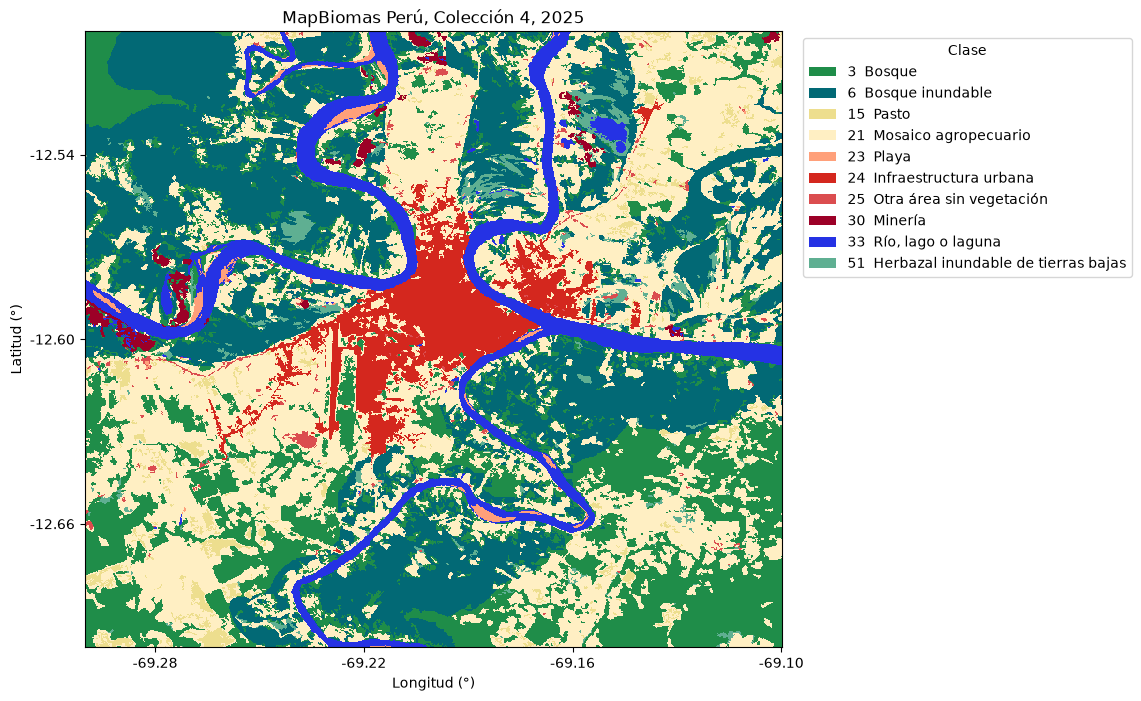

In [5]:
# Nombres y colores de las clases (ver la leyenda en las referencias)
LEYENDA = {
    3:  ("Bosque", "#1f8d49"),
    6:  ("Bosque inundable", "#026975"),
    15: ("Pasto", "#edde8e"),
    21: ("Mosaico agropecuario", "#ffefc3"),
    23: ("Playa", "#ffa07a"),
    24: ("Infraestructura urbana", "#d4271e"),
    25: ("Otra área sin vegetación", "#db4d4f"),
    30: ("Minería", "#9c0027"),
    33: ("Río, lago o laguna", "#2532e4"),
    51: ("Herbazal inundable de tierras bajas", "#5faf92"),
}

codigos = np.unique(mb.values[~np.isnan(mb.values)]).astype(int)
nombres = [LEYENDA.get(c, (f"Clase {c}", "#999999"))[0] for c in codigos]
colores = [LEYENDA.get(c, (f"Clase {c}", "#999999"))[1] for c in codigos]

idx = np.where(np.isnan(mb.values), np.nan, np.searchsorted(codigos, mb.values))
mb_idx = mb.copy(data=idx)

fig, ax = plt.subplots(figsize=(9, 8))
mb_idx.plot(
    ax=ax, cmap=ListedColormap(colores),
    vmin=-0.5, vmax=len(codigos) - 0.5, add_colorbar=False,
)
ax.legend(
    handles=[Patch(facecolor=c, label=f"{k}  {n}") for k, n, c in zip(codigos, nombres, colores)],
    loc="upper left", bbox_to_anchor=(1.02, 1), title="Clase",
)
ax.set_title("MapBiomas Perú, Colección 4, 2025")
ax.set_xlabel("Longitud (°)")
ax.set_ylabel("Latitud (°)")
for eje in (ax.xaxis, ax.yaxis):
    eje.set_major_locator(MaxNLocator(4))
    eje.set_major_formatter(FormatStrFormatter("%.2f"))
plt.show()

## Parte 2. Escena despejada y NDVI

Se obtiene una escena de Sentinel-2 L2A de la época seca de 2025 (julio a septiembre) sobre la zona de trabajo. Debe cubrir toda la zona y tener la menor nubosidad posible. Luego se calcula el NDVI a partir de valores de reflectancia.

Se puede acceder a los datos por Planetary Computer o por GEE, adaptando lo visto en los notebooks de la clase anterior.


In [6]:
#Importar librerías necesarias para trabajar con STAC y Planetary Computer o GEE
import planetary_computer
import pystac_client

In [7]:
catalogo = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

items = catalogo.search(
    collections=["sentinel-2-l2a"],
    bbox=BBOX,
    datetime="2025-07-01/2025-09-30",
    query={"eo:cloud_cover": {"lt": 20}},
).item_collection()

cubren = [
    i for i in items
    if i.bbox[0] <= BBOX[0] and i.bbox[1] <= BBOX[1]
    and i.bbox[2] >= BBOX[2] and i.bbox[3] >= BBOX[3]
]
assert cubren, "Ninguna escena cubre la zona completa; amplía las fechas o el umbral de nubes"

escena = planetary_computer.sign(min(cubren, key=lambda i: i.properties["eo:cloud_cover"]))
print(escena.id, escena.datetime.date(), escena.properties["eo:cloud_cover"], "% nubes")

S2A_MSIL2A_20250830T144751_R139_T19LDG_20250830T210014 2025-08-30 0.004375 % nubes


In [8]:
def leer_banda(item, clave, bbox):
    """Lee un asset recortado al AOI y lo convierte a reflectancia."""
    da = (
        rioxarray.open_rasterio(item.assets[clave].href, masked=True)
        .squeeze("band", drop=True)
        .rio.clip_box(*bbox, crs="EPSG:4326")
        .load()
    )
    linea_base = item.properties.get("s2:processing_baseline")
    assert linea_base is not None, f"Sin línea base en las propiedades: {list(item.properties)}"
    offset = -0.1 if float(linea_base) >= 4.0 else 0.0
    return (da * 0.0001 + offset).clip(min=0)

rojo = leer_banda(escena, "B04", BBOX)
nir = leer_banda(escena, "B08", BBOX)
ndvi = ((nir - rojo) / (nir + rojo)).astype("float32")

In [9]:
# Verificación
print(type(ndvi).__name__, ndvi.shape, ndvi.rio.crs)
print(f"NDVI mín {float(ndvi.min()):.2f}  máx {float(ndvi.max()):.2f}")

DataArray (2214, 2175) EPSG:32719
NDVI mín -0.50  máx 0.93


¿Es físicamente razonable el rango del NDVI? Justifica en una línea.

## Parte 3. Transecto de NDVI y cobertura

Se traza un transecto dentro de la zona de trabajo que cruce al menos tres coberturas distintas. 

Se grafica una figura con el perfil de NDVI en la que se identifique la cobertura de cada tramo, junto a un mapa que muestre dónde está el transecto.

In [10]:
# El NDVI está en UTM y MapBiomas en grados. Se lleva el NDVI a grados para muestrear ambos con lon y lat
ndvi_deg = ndvi.rio.reproject("EPSG:4326")

# Extracción del transecto (lon, lat), elegidos tras ver el mapa
P0, P1 = (-69.27, -12.66), (-69.14, -12.55)
n = 300
lons = np.linspace(P0[0], P1[0], n)
lats = np.linspace(P0[1], P1[1], n)
punto = xr.DataArray(np.arange(n), dims="punto")
lon_p = xr.DataArray(lons, dims="punto")
lat_p = xr.DataArray(lats, dims="punto")

# NDVI es continuo, por eso se interpola. La clase es categórica, por eso se toma el vecino más cercano
ndvi_t = ndvi_deg.interp(x=lon_p, y=lat_p, method="linear")
clase_t = mb.sel(x=lon_p, y=lat_p, method="nearest")

# Distancia a lo largo del transecto (km), aproximación válida para tramos cortos
# Cada tramo entre puntos consecutivos es la hipotenusa de su desplazamiento norte-sur
# y este-oeste (corregido por cos(lat)), y la distancia es la suma acumulada de los tramos
R = 6371.0  # radio medio de la Tierra (km)
dlat = np.radians(np.diff(lats))
dlon = np.radians(np.diff(lons))
lat_med = np.radians((lats[1:] + lats[:-1]) / 2)
paso = R * np.sqrt(dlat**2 + (np.cos(lat_med) * dlon) ** 2)
distancia_km = np.concatenate([[0], np.cumsum(paso)]) # el primer punto está a distancia 0

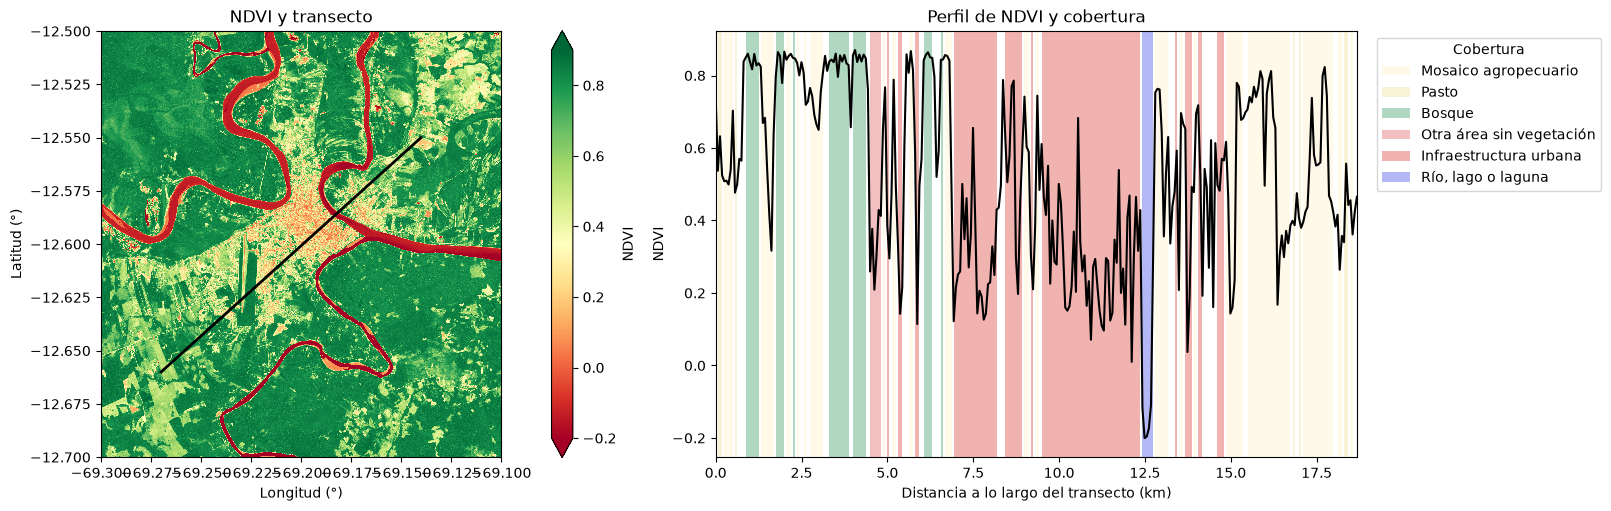

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1.6]},constrained_layout=True)

# Mapa con el transecto
ndvi_deg.plot(ax=axes[0], cmap="RdYlGn", vmin=-0.2, vmax=0.9, extend="both",
                     cbar_kwargs={"label": "NDVI"})
axes[0].plot(lons, lats, color="k", lw=2)
axes[0].set_title("NDVI y transecto")
axes[0].set_xlabel("Longitud (°)")
axes[0].set_ylabel("Latitud (°)")

# Perfil de NDVI con sombreado por clase
# El loop recorre los puntos y agrupa los tramos consecutivos de una misma clase.
# Al cambiar la clase, sombrea el tramo anterior con el color de esa clase
# y la guarda en `presentes` para armar la leyenda.
clase = clase_t.values
inicio = 0
presentes = []
for i in range(1, len(clase) + 1):
    if i == len(clase) or clase[i] != clase[inicio]:
        c = clase[inicio]
        if not np.isnan(c):
            color = LEYENDA.get(int(c), ("", "#999999"))[1]
            axes[1].axvspan(distancia_km[inicio], distancia_km[i - 1], color=color, alpha=0.35, lw=0)
            if int(c) not in presentes:
                presentes.append(int(c))
        inicio = i

axes[1].plot(distancia_km, ndvi_t.values, color="k", lw=1.5)
axes[1].set_xlim(distancia_km[0], distancia_km[-1])
axes[1].set_xlabel("Distancia a lo largo del transecto (km)")
axes[1].set_ylabel("NDVI")
axes[1].set_title("Perfil de NDVI y cobertura")
axes[1].legend(
    # Un cuadrado de color por cada clase presente en el transecto, con el mismo color y transparencia (alpha) que el sombreado
    # LEYENDA.get(c, (nombre, color)) devuelve (nombre, color) de la clase; si el código no está en LEYENDA usa "Clase c" y gris
    # [1] toma el color y [0] toma el nombre
    handles=[Patch(facecolor=LEYENDA.get(c, (f"Clase {c}", "#999999"))[1], alpha=0.35,
                   label=LEYENDA.get(c, (f"Clase {c}", "#999999"))[0]) for c in presentes],
    loc="upper left", bbox_to_anchor=(1.02, 1), title="Cobertura",
)

plt.show()